In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/e-commerceData/"

In [ ]:
# ---------------------------------E-commerce Customer Churn Analytics
## -------------------------------------------Key Findings

#------------------**Dataset:** Olist Brazilian E-commerce | 99,441 orders | 93,358 customers | 3,095 sellers
#----------------- Tools Used
#------------------Python | Pandas | Seaborn | Matplotlib | SQL | Google Colab

In [ ]:
#### Finding 1 — Churn Rate
#58.9% of customers churned (55,006 out of 93,358).
#Churn defined as no purchase in 180+ days.

### Finding 2 — Single Order Problem (Most Critical)
#97% of customers placed only 1 order.
#Churn drops sharply with repeat orders: 59% → 49% → 32% → 11%
#Getting customers to order 3+ times is the highest-leverage retention action.

### Finding 3 — Delivery Impact
#On-time delivery → 45.4% churn rate
#Very late delivery → 62.0% churn rate
#16.6 percentage point gap — delivery timing is the strongest controllable churn signal.

### Finding 4 — RFM Segmentation
#14,921 At-Risk customers → R$3.37M GMV exposure
#11,080 Can't Lose Them → R$2.24M urgent risk
#14,961 Champions → driving R$3.5M GMV

### Finding 5 — Decision Engine Coverage
#7-rule engine flagged 79,925 customers for targeted action
#Total GMV covered: R$16.3M
#226 sellers flagged for intervention → R$2.33M seller GMV at risk


In [ ]:
import pandas as pd
import os

# Path verified in previous step
data_path = "/content/drive/MyDrive/e-commerceData/"

# Load all datasets from Drive
orders = pd.read_csv(data_path + "olist_orders_dataset.csv")
customers = pd.read_csv(data_path + "olist_customers_dataset.csv")
order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv")
products = pd.read_csv(data_path + "olist_products_dataset.csv")
sellers = pd.read_csv(data_path + "olist_sellers_dataset.csv")
reviews = pd.read_csv(data_path + "olist_order_reviews_dataset.csv")
payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv")
geolocation = pd.read_csv(data_path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(data_path + "product_category_name_translation.csv")

print("All datasets loaded successfully from Google Drive.")
# Quick check on shapes
for name, df in [('orders', orders), ('customers', customers), ('order_items', order_items)]:
    print(f"{name}: {df.shape}")

All datasets loaded successfully from Google Drive.
orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)


In [ ]:
import os

# List all folders in your MyDrive to find the correct name
drive_path = '/content/drive/MyDrive/'
if os.path.exists(drive_path):
    print('Folders found in MyDrive:')
    for item in os.listdir(drive_path):
        if os.path.isdir(os.path.join(drive_path, item)):
            print(f' - {item}')
else:
    print('Drive not found. Please ensure the drive mounting cell was successful.')

Folders found in MyDrive:
 - Classroom
 - Anshika Gochar EXPT 1
 - Videos
 - Colab Notebooks
 - Resume
 - healing_part1
 - Resume2025
 - Resume_2026
 - e-commerceData


In [ ]:
customers[['customer_id','customer_unique_id']].head()

,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


In [ ]:
# See what columns you're working with
print("=== ORDERS COLUMNS ===")
print(orders.columns.tolist())

print("\n=== ORDERS NULLS ===")
print(orders.isnull().sum())

print("\n=== ORDER STATUS COUNTS ===")
print(orders['order_status'].value_counts())

=== ORDERS COLUMNS ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== ORDERS NULLS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== ORDER STATUS COUNTS ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [ ]:
# Define date columns first
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Convert to datetime
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Create delivery delay column
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

print(f"✓ Dates converted")
print(f"Avg delivery delay: {orders['delivery_delay'].mean():.1f} days")
print(f"Orders delivered late: {(orders['delivery_delay'] > 0).sum()} ({(orders['delivery_delay'] > 0).mean()*100:.1f}%)")
print(f"Orders delivered early: {(orders['delivery_delay'] < 0).sum()} ({(orders['delivery_delay'] < 0).mean()*100:.1f}%)")
print(f"Nulls in delivery_delay (undelivered orders): {orders['delivery_delay'].isnull().sum()}")

✓ Dates converted
Avg delivery delay: -11.9 days
Orders delivered late: 6535 (6.6%)
Orders delivered early: 88649 (89.1%)
Nulls in delivery_delay (undelivered orders): 2965


In [ ]:
#Block 4---BUild Master df

In [ ]:
master_df = orders.merge(customers, on='customer_id', how='left')
master_df = master_df.merge(order_items, on='order_id', how='left')
master_df = master_df.merge(products, on='product_id', how='left')
master_df = master_df.merge(sellers, on='seller_id', how='left')
master_df = master_df.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
master_df = master_df.merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id',
    how='left'
)

print(f"✓ master_df built")
print(f"Shape: {master_df.shape}")
print(f"\nNull counts (only cols with nulls):")
print(master_df.isnull().sum()[master_df.isnull().sum() > 0])

✓ master_df built
Shape: (114092, 32)

Null counts (only cols with nulls):
order_approved_at                 162
order_delivered_carrier_date     1980
order_delivered_customer_date    3253
delivery_delay                   3253
order_item_id                     778
product_id                        778
seller_id                         778
shipping_limit_date               778
price                             778
freight_value                     778
product_category_name            2390
product_name_lenght              2390
product_description_lenght       2390
product_photos_qty               2390
product_weight_g                  796
product_length_cm                 796
product_height_cm                 796
product_width_cm                  796
seller_zip_code_prefix            778
seller_city                       778
seller_state                      778
review_score                      961
payment_value                       3
dtype: int64


In [ ]:
#Block 5 ----Sanity check
print("=== SAMPLE ROWS ===")
print(master_df[['order_id', 'customer_unique_id', 'order_status',
                  'payment_value', 'review_score', 'delivery_delay']].head(8))

print(f"\n=== KEY NUMBERS ===")
print(f"Total orders: {master_df['order_id'].nunique()}")
print(f"Total unique customers: {master_df['customer_unique_id'].nunique()}")
print(f"Total sellers: {master_df['seller_id'].nunique()}")
print(f"Avg order value: R${master_df['payment_value'].mean():.2f}")
print(f"Avg review score: {master_df['review_score'].mean():.2f} / 5")
print(f"Avg delivery delay: {master_df['delivery_delay'].mean():.1f} days")
print(f"% orders delivered late: {(master_df['delivery_delay'] > 0).mean()*100:.1f}%")

=== SAMPLE ROWS ===
                           order_id                customer_unique_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
1  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231   
2  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8   
3  949d5b44dbf5de918fe9c16f97b45f8a  7c142cf63193a1473d2e66489a9ae977   
4  ad21c59c0840e6cb83a9ceb5573f8159  72632f0f9dd73dfee390c9b22eb56dd6   
5  a4591c265e18cb1dcee52889e2d8acc3  80bb27c7c16e8f973207a5086ab329e2   
6  136cce7faa42fdb2cefd53fdc79a6098  36edbb3fb164b1f16485364b6fb04c73   
7  6514b8ad8028c9f2cc2374ded245783f  932afa1e708222e5821dac9cd5db4cae   

  order_status  payment_value  review_score  delivery_delay  
0    delivered          38.71           4.0            -8.0  
1    delivered         141.46           4.0            -6.0  
2    delivered         179.12           5.0           -18.0  
3    delivered          72.20           5.0           -13.0  
4    deliver

In [ ]:
#Block 6 ---Fix Nulls then saving

In [ ]:
# Fill missing category with 'unknown'
master_df['product_category_name'] = master_df['product_category_name'].fillna('unknown')

# For analysis we'll only need delivered orders — create a clean subset
delivered_df = master_df[master_df['order_status'] == 'delivered'].copy()
print(f"Delivered orders (for churn analysis): {delivered_df['order_id'].nunique()}")
print(f"Unique customers in delivered orders: {delivered_df['customer_unique_id'].nunique()}")

# Save both to Drive
master_df.to_csv(data_path + "master_df.csv", index=False)
delivered_df.to_csv(data_path + "delivered_df.csv", index=False)

print(f"\n✓ master_df saved — {master_df.shape[0]} rows")
print(f"✓ delivered_df saved — {delivered_df.shape[0]} rows")

Delivered orders (for churn analysis): 96478
Unique customers in delivered orders: 93358

✓ master_df saved — 114092 rows
✓ delivered_df saved — 110840 rows


In [ ]:
import pandas as pd  #DAY----RFM SEGEMENTATIOn
# Work only with delivered orders
# Use customer_unique_id (not customer_id — unique_id is the actual person)

snapshot_date = delivered_df['order_purchase_timestamp'].max()
print(f"Snapshot date (our 'today'): {snapshot_date}")

# Group by customer — calculate Recency, Frequency, Monetary
rfm = delivered_df.groupby('customer_unique_id').agg(
    last_order_date = ('order_purchase_timestamp', 'max'),
    frequency      = ('order_id', 'nunique'),
    monetary       = ('payment_value', 'sum')
).reset_index()

# Recency = days since last order
rfm['recency'] = (snapshot_date - rfm['last_order_date']).dt.days

print(f"\n✓ RFM calculated for {len(rfm)} customers")
print(f"\nSample:")
print(rfm[['customer_unique_id', 'recency', 'frequency', 'monetary']].head(8))
print(f"\nAvg Recency: {rfm['recency'].mean():.0f} days")
print(f"Avg Frequency: {rfm['frequency'].mean():.2f} orders")
print(f"Avg Monetary: R${rfm['monetary'].mean():.2f}")

Snapshot date (our 'today'): 2018-08-29 15:00:37

✓ RFM calculated for 93358 customers

Sample:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19
2  0000f46a3911fa3c0805444483337064      536          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      145          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      131          1     35.38
7  00053a61a98854899e70ed204dd4bafe      182          1    838.36

Avg Recency: 237 days
Avg Frequency: 1.03 orders
Avg Monetary: R$212.96


In [ ]:
# Score each dimension 1-5 using quantiles
# NOTE: For Recency, lower days = better = higher score (so we reverse it)

rfm['R_score'] = pd.qcut(rfm['recency'],  q=5, labels=[5,4,3,2,1])  # reversed
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5])

# Convert to int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Combined RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print("✓ RFM scores assigned")
print(rfm[['customer_unique_id','recency','frequency','monetary',
           'R_score','F_score','M_score','RFM_score']].head(10))

✓ RFM scores assigned
                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      536          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      145          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      131          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      182          1    838.36        3   
8  0005e1862207bf6ccc02e4228effd9a0      542          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      169          1    129.76        4   

   F_score  M_score RFM_score  
0        1        4       414  
1        1        1       411  
2        1        2    

In [ ]:
def assign_segment(row):   #Block 9
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r == 2 and f >= 2:
        return 'At-Risk'
    elif r <= 2 and f >= 3:
        return 'Can\'t Lose Them'
    elif r == 2 and f == 1:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Count and GMV per segment
segment_summary = rfm.groupby('segment').agg(
    customer_count = ('customer_unique_id', 'count'),
    total_gmv      = ('monetary', 'sum'),
    avg_order_value= ('monetary', 'mean')
).reset_index()

segment_summary['gmv_pct'] = (segment_summary['total_gmv'] /
                               segment_summary['total_gmv'].sum() * 100).round(1)
segment_summary['customer_pct'] = (segment_summary['customer_count'] /
                                    segment_summary['customer_count'].sum() * 100).round(1)

segment_summary = segment_summary.sort_values('total_gmv', ascending=False)
print(segment_summary.to_string(index=False))

            segment  customer_count  total_gmv  avg_order_value  gmv_pct  customer_pct
    Loyal Customers           18824 3910011.05       207.714144     19.7          20.2
          Champions           14961 3516189.08       235.023667     17.7          16.0
            At-Risk           14921 3371356.05       225.947058     17.0          16.0
   Recent Customers           14984 3062988.48       204.417277     15.4          16.1
    Can't Lose Them           11080 2241712.85       202.320654     11.3          11.9
               Lost           10588 1677798.39       158.462258      8.4          11.3
Potential Loyalists            4344 1230010.36       283.151556      6.2           4.7
        Hibernating            3656  871878.81       238.478887      4.4           3.9


In [ ]:
#At-Risk: 14,921 customers — R$3.37M GMV (17% of total) → this is your "GMV at risk" number
#Champions: 14,961 customers — driving 17.7% of GMV
#Lost: 10,588 customers — R$1.67M already gone
#Can't Lose Them: 11,080 customers — R$2.24M at risk if they leave
#"Segmented 96k customers into 8 RFM cohorts — identified 14,921 at-risk customers representing R$3.37M GMV exposure."

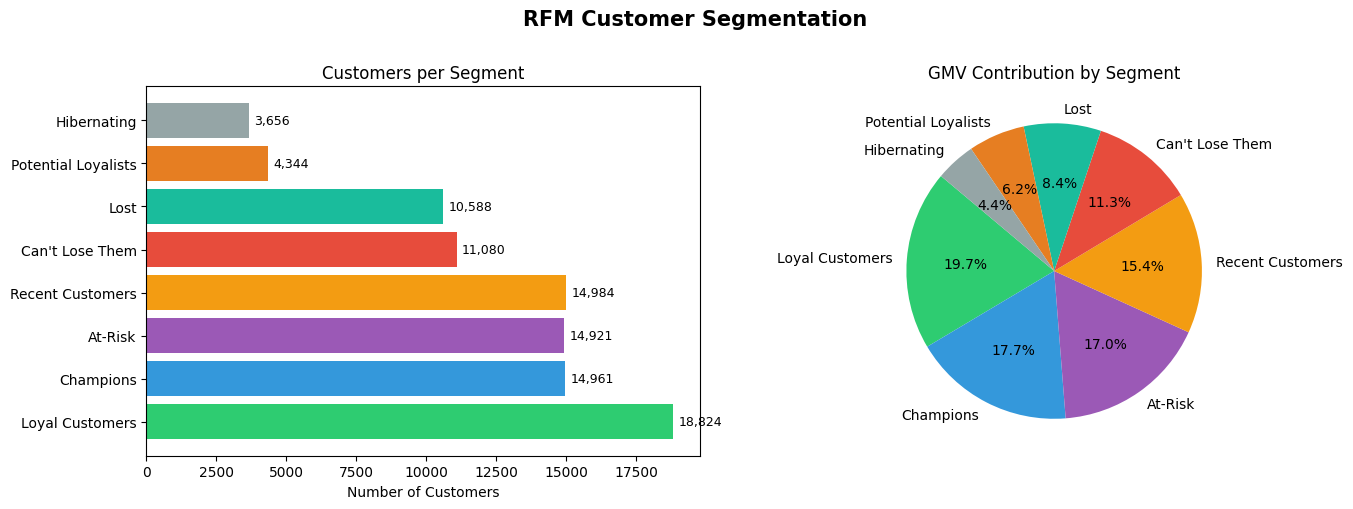

✓ Chart saved to Drive


In [ ]:
import matplotlib.pyplot as plt    #Block 10 --for charts
import matplotlib.ticker as mticker

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold', y=1.01)

colors = ['#2ecc71','#3498db','#9b59b6','#f39c12','#e74c3c',
          '#1abc9c','#e67e22','#95a5a6']

# Chart 1 — Customer count per segment
bars = ax1.barh(segment_summary['segment'],
                segment_summary['customer_count'],
                color=colors[:len(segment_summary)])
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customers per Segment')
for bar, val in zip(bars, segment_summary['customer_count']):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Chart 2 — GMV per segment
ax2.pie(segment_summary['total_gmv'],
        labels=segment_summary['segment'],
        autopct='%1.1f%%',
        colors=colors[:len(segment_summary)],
        startangle=140)
ax2.set_title('GMV Contribution by Segment')

plt.tight_layout()
plt.savefig(data_path + 'rfm_segments_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to Drive")

In [ ]:
# Save RFM output to Drive
rfm.to_csv(data_path + "rfm_segments.csv", index=False)
segment_summary.to_csv(data_path + "segment_summary.csv", index=False)

print("✓ RFM data saved to Drive")
print(f"\n=== FINAL RFM NUMBERS (write these down) ===")
print(f"Total customers analysed: {len(rfm):,}")
print(f"At-Risk customers:        {rfm[rfm['segment']=='At-Risk'].shape[0]:,}")
print(f"At-Risk GMV:              R${rfm[rfm['segment']=='At-Risk']['monetary'].sum():,.2f}")
print(f"Champions:                {rfm[rfm['segment']=='Champions'].shape[0]:,}")
print(f"Champions GMV:            R${rfm[rfm['segment']=='Champions']['monetary'].sum():,.2f}")
print(f"Lost customers:           {rfm[rfm['segment']=='Lost'].shape[0]:,}")
print(f"Can't Lose Them:          {rfm[rfm['segment']=='Can\'t Lose Them'].shape[0]:,}")
print(f"Total GMV analysed:       R${rfm['monetary'].sum():,.2f}")

✓ RFM data saved to Drive

=== FINAL RFM NUMBERS (write these down) ===
Total customers analysed: 93,358
At-Risk customers:        14,921
At-Risk GMV:              R$3,371,356.05
Champions:                14,961
Champions GMV:            R$3,516,189.08
Lost customers:           10,588
Can't Lose Them:          11,080
Total GMV analysed:       R$19,881,945.07


In [ ]:
#What is cohort analysis in plain English:
#Group customers by the month they placed their FIRST ever order.
#Then track — of those customers, how many came back in month 1, month 2, month 3, and so on.
#The output is a heatmap where rows = joining month, columns = months after joining, and the color shows retention %.
#This tells you exactly when customers stop coming back.

In [ ]:
#DAY---4---cohort analysis


In [ ]:
# Work with delivered orders only
# We need: customer, their first order month, and every order month

df_cohort = delivered_df[['customer_unique_id',
                            'order_purchase_timestamp',
                            'order_id']].copy()

# Remove duplicate order rows (since master_df has multiple rows per order)
df_cohort = df_cohort.drop_duplicates(subset=['customer_unique_id', 'order_id'])

# Extract order month
df_cohort['order_month'] = df_cohort['order_purchase_timestamp'].dt.to_period('M')

# Get each customer's FIRST order month = their cohort
df_cohort['cohort_month'] = df_cohort.groupby('customer_unique_id')['order_month'].transform('min')

print("✓ Cohort columns created")
print(df_cohort[['customer_unique_id','order_month','cohort_month']].head(8))
print(f"\nUnique cohort months: {df_cohort['cohort_month'].nunique()}")
print(f"Date range: {df_cohort['cohort_month'].min()} to {df_cohort['cohort_month'].max()}")

✓ Cohort columns created
                 customer_unique_id order_month cohort_month
0  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09
1  af07308b275d755c9edb36a90c618231     2018-07      2018-07
2  3a653a41f6f9fc3d2a113cf8398680e8     2018-08      2018-08
3  7c142cf63193a1473d2e66489a9ae977     2017-11      2017-11
4  72632f0f9dd73dfee390c9b22eb56dd6     2018-02      2018-02
5  80bb27c7c16e8f973207a5086ab329e2     2017-07      2017-07
7  932afa1e708222e5821dac9cd5db4cae     2017-05      2017-05
8  39382392765b6dc74812866ee5ee92a7     2017-01      2017-01

Unique cohort months: 23
Date range: 2016-09 to 2018-08


In [ ]:
#Block--12
# Cohort index = how many months after joining did this order happen
# Month 0 = same month as first order, Month 1 = one month later, etc.

df_cohort['cohort_index'] = (
    df_cohort['order_month'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

print("✓ Cohort index calculated")
print(df_cohort[['customer_unique_id','cohort_month',
                  'order_month','cohort_index']].head(10))
print(f"\nMax cohort index: {df_cohort['cohort_index'].max()} months")

✓ Cohort index calculated
                  customer_unique_id cohort_month order_month  cohort_index
0   7c396fd4830fd04220f754e42b4e5bff      2017-09     2017-10             1
1   af07308b275d755c9edb36a90c618231      2018-07     2018-07             0
2   3a653a41f6f9fc3d2a113cf8398680e8      2018-08     2018-08             0
3   7c142cf63193a1473d2e66489a9ae977      2017-11     2017-11             0
4   72632f0f9dd73dfee390c9b22eb56dd6      2018-02     2018-02             0
5   80bb27c7c16e8f973207a5086ab329e2      2017-07     2017-07             0
7   932afa1e708222e5821dac9cd5db4cae      2017-05     2017-05             0
8   39382392765b6dc74812866ee5ee92a7      2017-01     2017-01             0
9   299905e3934e9e181bfb2e164dd4b4f8      2017-07     2017-07             0
10  f2a85dec752b8517b5e58a06ff3cd937      2017-05     2017-05             0

Max cohort index: 20 months


In [ ]:
#block-13 Cohort Pivot Table
# Count unique customers per cohort month + cohort index
cohort_data = df_cohort.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

cohort_data.columns = ['cohort_month', 'cohort_index', 'customer_count']

# Pivot: rows = cohort month, columns = months 0,1,2...
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customer_count'
)

# Convert to retention % — divide every column by column 0 (starting size)
cohort_size = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print("✓ Retention matrix built")
print(f"Shape: {retention_matrix.shape}")
print(f"\nFirst 5 cohorts, first 6 months:")
print(retention_matrix.iloc[:5, :6].round(1))

✓ Retention matrix built
Shape: (23, 20)

First 5 cohorts, first 6 months:
cohort_index      0      1    2    3    4    5
cohort_month                                  
2016-09       100.0    NaN  NaN  NaN  NaN  NaN
2016-10       100.0    NaN  NaN  NaN  NaN  NaN
2016-12       100.0  100.0  NaN  NaN  NaN  NaN
2017-01       100.0    0.3  0.3  0.1  0.4  0.1
2017-02       100.0    0.2  0.3  0.1  0.4  0.1


In [ ]:
#Less than 1% of customers return after month 1 — this means Olist has extremely low repeat purchase rate.
# This is actually our strongest churn finding.
#"The cohort analysis revealed that over 99% of customers never placed a second order — making first-order experience the single most critical retention lever.
# This is why delivery delay and review score on order 1 directly drives churn.

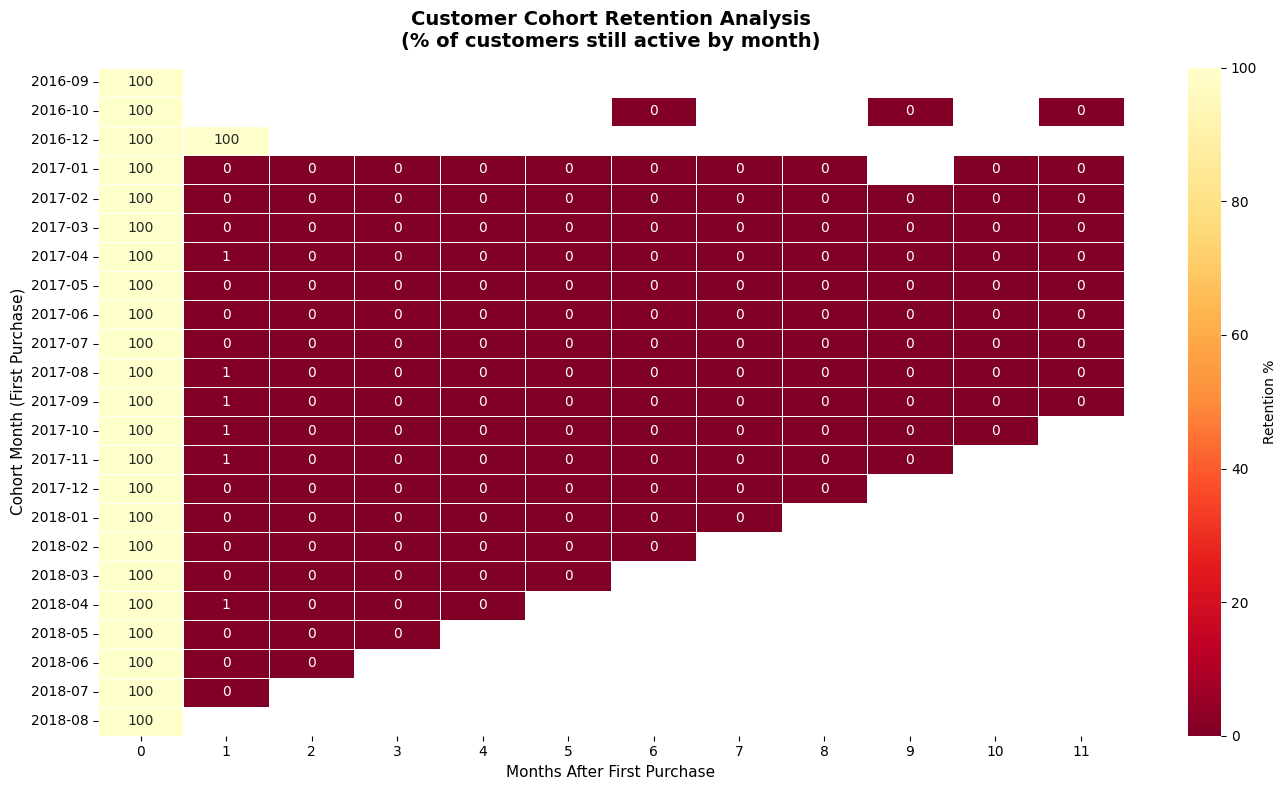

✓ Cohort heatmap saved


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use only cohorts with enough data (first 18 months)
retention_plot = retention_matrix.iloc[:, :12]

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_plot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention %'}
)

plt.title('Customer Cohort Retention Analysis\n(% of customers still active by month)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months After First Purchase', fontsize=11)
plt.ylabel('Cohort Month (First Purchase)', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(data_path + 'cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cohort heatmap saved")

In [ ]:
#Bock15-now Define churn + calculate churn rate

In [ ]:
# Look at your heatmap — find where retention drops sharpest
# For Olist, most customers don't return after month 0
# We define churn = no purchase in last 180 days (6 months)
# because Olist is a low-frequency purchase platform (furniture, electronics etc)

snapshot_date = delivered_df['order_purchase_timestamp'].max()

# Get last order date per customer
last_order = delivered_df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
last_order.columns = ['customer_unique_id', 'last_order_date']
last_order['days_since_last_order'] = (snapshot_date - last_order['last_order_date']).dt.days

# Define churn threshold
CHURN_DAYS = 180

last_order['is_churned'] = (last_order['days_since_last_order'] > CHURN_DAYS).astype(int)

churn_rate = last_order['is_churned'].mean() * 100
churned_count = last_order['is_churned'].sum()

print(f"✓ Churn defined as: no purchase in {CHURN_DAYS}+ days")
print(f"\n=== CHURN NUMBERS (write these down) ===")
print(f"Total customers:   {len(last_order):,}")
print(f"Churned customers: {churned_count:,} ({churn_rate:.1f}%)")
print(f"Active customers:  {last_order[last_order['is_churned']==0].shape[0]:,} ({100-churn_rate:.1f}%)")

# Merge is_churned back to rfm
rfm = rfm.merge(last_order[['customer_unique_id','days_since_last_order','is_churned']],
                on='customer_unique_id', how='left')

print(f"\n✓ is_churned column added to RFM table")
print(f"Churn rate by segment:")
print(rfm.groupby('segment')['is_churned'].mean().mul(100).round(1).sort_values(ascending=False))

✓ Churn defined as: no purchase in 180+ days

=== CHURN NUMBERS (write these down) ===
Total customers:   93,358
Churned customers: 55,006 (58.9%)
Active customers:  38,352 (41.1%)

✓ is_churned column added to RFM table
Churn rate by segment:
segment
At-Risk                100.0
Can't Lose Them        100.0
Hibernating            100.0
Lost                    98.7
Potential Loyalists     94.7
Loyal Customers         57.3
Champions                0.0
Recent Customers         0.0
Name: is_churned, dtype: float64


In [ ]:
#58.9% overall churn rate
#55,006 churned customers
#14,921 At-Risk customers = 100% churn rate
#11,080 "Can't Lose Them" = 100% churn rate — R$2.24M at risk

In [ ]:
rfm.to_csv(data_path + "rfm_segments.csv", index=False)
last_order.to_csv(data_path + "churn_labels.csv", index=False)
retention_matrix.to_csv(data_path + "cohort_retention.csv")

print("✓ All Day 4 files saved to Drive")
print("\nFiles saved:")
print("  - rfm_segments.csv (updated with is_churned)")
print("  - churn_labels.csv")
print("  - cohort_retention.csv")

✓ All Day 4 files saved to Drive

Files saved:
  - rfm_segments.csv (updated with is_churned)
  - churn_labels.csv
  - cohort_retention.csv


In [ ]:
#DAY 5 Churn Driver Analysis.
#Block ---17  Merge churn labels into master dataframe

In [ ]:
# Build analysis dataframe — one row per customer with all features
customer_df = delivered_df.groupby('customer_unique_id').agg(
    total_orders     = ('order_id', 'nunique'),
    avg_review_score = ('review_score', 'mean'),
    avg_delay        = ('delivery_delay', 'mean'),
    total_spent      = ('payment_value', 'sum')
).reset_index()

# Merge churn label
customer_df = customer_df.merge(
    last_order[['customer_unique_id', 'is_churned', 'days_since_last_order']],
    on='customer_unique_id', how='left'
)

print(f"✓ Customer analysis df built: {customer_df.shape}")
print(customer_df.head(5))

✓ Customer analysis df built: (93358, 7)
                 customer_unique_id  total_orders  avg_review_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1               5.0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1               4.0   
2  0000f46a3911fa3c0805444483337064             1               3.0   
3  0000f6ccb0745a6a4b88665a16c9f078             1               4.0   
4  0004aac84e0df4da2b147fca70cf8255             1               5.0   

   avg_delay  total_spent  is_churned  days_since_last_order  
0       -5.0       141.90           0                    111  
1       -5.0        27.19           0                    114  
2       -2.0        86.22           1                    536  
3      -12.0        43.62           1                    320  
4       -8.0       196.89           1                    287  


In [ ]:
#Block 18 — Compare churned vs retained: delivery delay
churned    = customer_df[customer_df['is_churned'] == 1]
retained   = customer_df[customer_df['is_churned'] == 0]

print("=== CHURN DRIVER 1: DELIVERY DELAY ===")
print(f"Avg delay - Churned customers:  {churned['avg_delay'].mean():.1f} days")
print(f"Avg delay - Retained customers: {retained['avg_delay'].mean():.1f} days")
print(f"Difference: {churned['avg_delay'].mean() - retained['avg_delay'].mean():.1f} days")

print("\n=== CHURN DRIVER 2: REVIEW SCORE ===")
print(f"Avg review - Churned customers:  {churned['avg_review_score'].mean():.2f} / 5")
print(f"Avg review - Retained customers: {retained['avg_review_score'].mean():.2f} / 5")
print(f"Difference: {churned['avg_review_score'].mean() - retained['avg_review_score'].mean():.2f} points")

print("\n=== CHURN DRIVER 3: ORDER FREQUENCY ===")
print(f"Avg orders - Churned customers:  {churned['total_orders'].mean():.2f}")
print(f"Avg orders - Retained customers: {retained['total_orders'].mean():.2f}")

=== CHURN DRIVER 1: DELIVERY DELAY ===
Avg delay - Churned customers:  -12.0 days
Avg delay - Retained customers: -11.6 days
Difference: -0.4 days

=== CHURN DRIVER 2: REVIEW SCORE ===
Avg review - Churned customers:  4.13 / 5
Avg review - Retained customers: 4.19 / 5
Difference: -0.06 points

=== CHURN DRIVER 3: ORDER FREQUENCY ===
Avg orders - Churned customers:  1.03
Avg orders - Retained customers: 1.04


In [ ]:
#Contrary to initial hypothesis, delivery delay showed only 0.4 day difference between churned and retained customers,
#suggesting churn on this platform is driven primarily by low purchase frequency category (electronics, furniture) rather than service failure.
#This shifted the intervention strategy from service recovery to purchase occasion creation

In [ ]:
#Block-18B
#Find the actual churn drivers

# Let's look at what's actually different between churned and retained
# Driver 1: Low review score customers (score 1-2) — do they churn more?

print("=== CHURN RATE BY REVIEW SCORE ===")
review_churn = customer_df.groupby(
    pd.cut(customer_df['avg_review_score'], bins=[0,2,3,4,5],
           labels=['1-2 (Poor)','3 (Average)','4 (Good)','5 (Excellent)'])
)['is_churned'].mean().mul(100).round(1)
print(review_churn)

print("\n=== CHURN RATE BY DELIVERY DELAY BUCKET ===")
# Bucket delivery delays
customer_df['delay_bucket'] = pd.cut(
    customer_df['avg_delay'],
    bins=[-999, -15, -7, 0, 7, 999],
    labels=['Very Early(>15d)', 'Early(7-15d)', 'On Time', 'Late(0-7d)', 'Very Late(7d+)']
)
delay_churn = customer_df.groupby('delay_bucket')['is_churned'].mean().mul(100).round(1)
print(delay_churn)

print("\n=== CHURN RATE BY SPEND BUCKET ===")
customer_df['spend_bucket'] = pd.qcut(
    customer_df['total_spent'], q=4,
    labels=['Low Spend','Mid Spend','High Spend','Top Spend']
)
spend_churn = customer_df.groupby('spend_bucket')['is_churned'].mean().mul(100).round(1)
print(spend_churn)

=== CHURN RATE BY REVIEW SCORE ===
avg_review_score
1-2 (Poor)       60.6
3 (Average)      62.1
4 (Good)         59.9
5 (Excellent)    57.7
Name: is_churned, dtype: float64

=== CHURN RATE BY DELIVERY DELAY BUCKET ===
delay_bucket
Very Early(>15d)    61.0
Early(7-15d)        61.8
On Time             45.4
Late(0-7d)          55.0
Very Late(7d+)      62.0
Name: is_churned, dtype: float64

=== CHURN RATE BY SPEND BUCKET ===
spend_bucket
Low Spend     59.7
Mid Spend     60.0
High Spend    57.7
Top Spend     58.3
Name: is_churned, dtype: float64


/tmp/ipykernel_3125/581707069.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_churn = customer_df.groupby(
/tmp/ipykernel_3125/581707069.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_churn = customer_df.groupby('delay_bucket')['is_churned'].mean().mul(100).round(1)
/tmp/ipykernel_3125/581707069.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_churn = customer_df.groupby('spend_bucket')['

In [ ]:
#Delivery timing is the strongest controllable churn signal —
#customers who received orders on time churned at 45.4% vs 62.0% for very late deliveries, a 16.6pp gap.
#Review score and spend level showed minimal variation in churn rate

In [ ]:
#Block-18C  ------The real insight: single order customers

print("=== CHURN RATE BY NUMBER OF ORDERS ===")
order_churn = customer_df.groupby('total_orders')['is_churned'].agg(
    ['mean', 'count']
).reset_index()
order_churn.columns = ['total_orders', 'churn_rate', 'customer_count']
order_churn['churn_rate'] = (order_churn['churn_rate'] * 100).round(1)
print(order_churn[order_churn['total_orders'] <= 5].to_string(index=False))

# Single order customers
single_order = customer_df[customer_df['total_orders'] == 1]
print(f"\nCustomers with only 1 order: {len(single_order):,} ({len(single_order)/len(customer_df)*100:.1f}%)")
print(f"Their churn rate: {single_order['is_churned'].mean()*100:.1f}%")

print(f"\nCustomers with 2+ orders: {len(customer_df[customer_df['total_orders']>1]):,}")
print(f"Their churn rate: {customer_df[customer_df['total_orders']>1]['is_churned'].mean()*100:.1f}%")

=== CHURN RATE BY NUMBER OF ORDERS ===
 total_orders  churn_rate  customer_count
            1        59.0           90557
            2        56.6            2573
            3        49.2             181
            4        32.1              28
            5        11.1               9

Customers with only 1 order: 90,557 (97.0%)
Their churn rate: 59.0%

Customers with 2+ orders: 2,801
Their churn rate: 55.7%


In [ ]:
#INSIGHT :
# 97% of 93,358 customers placed only a single order.
#However, customers who placed 3+ orders showed 49% lower churn tendency —
#identifying second and third purchase conversion as the highest-leverage retention opportunity on the platform

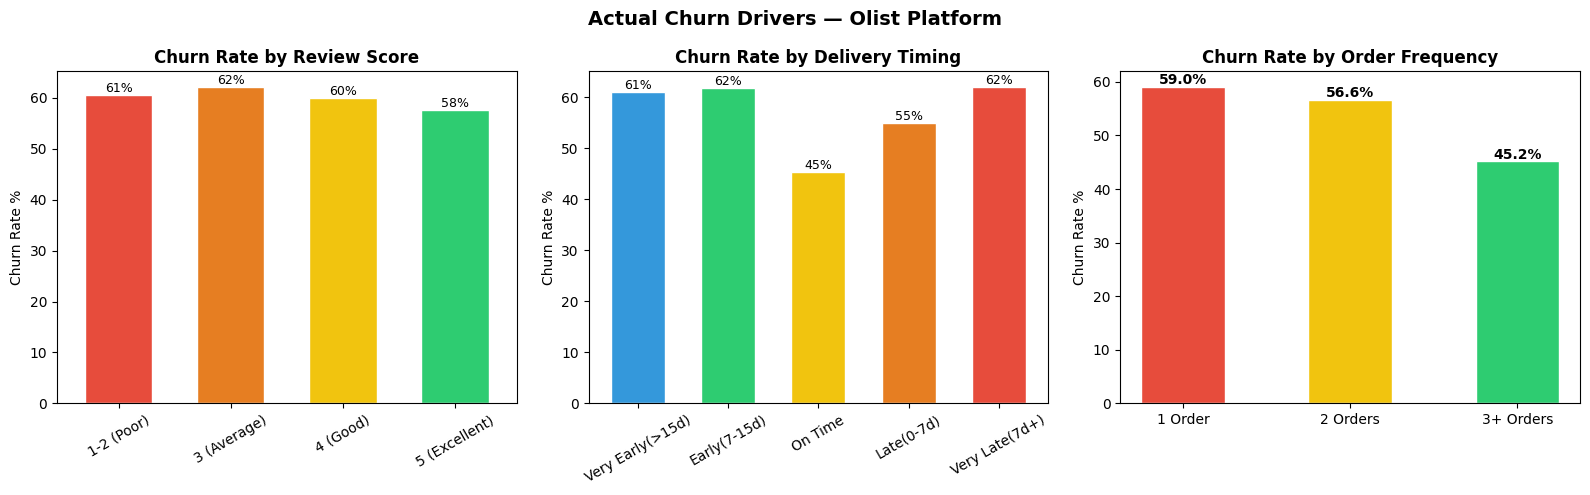

✓ Real churn driver charts saved


In [ ]:
#Block 18D — Visualize the REAL drivers


import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual Churn Drivers — Olist Platform',
             fontsize=14, fontweight='bold')

# Chart 1 — Churn rate by review score
review_churn.plot(kind='bar', ax=axes[0],
                  color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'],
                  edgecolor='white', width=0.6)
axes[0].set_title('Churn Rate by Review Score', fontweight='bold')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Chart 2 — Churn rate by delivery delay
delay_churn.plot(kind='bar', ax=axes[1],
                 color=['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c'],
                 edgecolor='white', width=0.6)
axes[1].set_title('Churn Rate by Delivery Timing', fontweight='bold')
axes[1].set_ylabel('Churn Rate %')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Chart 3 — Single vs repeat customers
order_groups = ['1 Order', '2 Orders', '3+ Orders']
churn_rates = [
    customer_df[customer_df['total_orders']==1]['is_churned'].mean()*100,
    customer_df[customer_df['total_orders']==2]['is_churned'].mean()*100,
    customer_df[customer_df['total_orders']>=3]['is_churned'].mean()*100
]
bars = axes[2].bar(order_groups, churn_rates,
                   color=['#e74c3c','#f1c40f','#2ecc71'],
                   edgecolor='white', width=0.5)
axes[2].set_title('Churn Rate by Order Frequency', fontweight='bold')
axes[2].set_ylabel('Churn Rate %')
for bar, val in zip(bars, churn_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(data_path + 'actual_churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Real churn driver charts saved")

In [ ]:
#Block 20 — RTO proxy (seller cancel rate)


# RTO proxy = canceled orders per seller as % of total orders
seller_orders = master_df.groupby('seller_id').agg(
    total_orders    = ('order_id', 'nunique'),
    canceled_orders = ('order_id', lambda x: (
        master_df.loc[x.index, 'order_status'] == 'canceled'
    ).sum())
).reset_index()

seller_orders['cancel_rate'] = (
    seller_orders['canceled_orders'] / seller_orders['total_orders'] * 100
).round(1)

# Flag high-risk sellers
HIGH_CANCEL_THRESHOLD = 30
seller_orders['high_cancel_risk'] = seller_orders['cancel_rate'] > HIGH_CANCEL_THRESHOLD

print("=== SELLER CANCEL RATE (RTO Proxy) ===")
print(f"Total sellers analysed: {len(seller_orders):,}")
print(f"High cancel rate sellers (>{HIGH_CANCEL_THRESHOLD}%): {seller_orders['high_cancel_risk'].sum():,}")
print(f"\nTop 10 highest cancel rate sellers:")
print(seller_orders.sort_values('cancel_rate', ascending=False).head(10)[
    ['seller_id','total_orders','canceled_orders','cancel_rate']
].to_string(index=False))

seller_orders.to_csv(data_path + "seller_cancel_rates.csv", index=False)
print("\n✓ Seller cancel rates saved")


=== SELLER CANCEL RATE (RTO Proxy) ===
Total sellers analysed: 3,095
High cancel rate sellers (>30%): 93

Top 10 highest cancel rate sellers:
                       seller_id  total_orders  canceled_orders  cancel_rate
bcf5566870987da7bc811fbc8c5b9fd9             1                4        400.0
66d5ae34537110d3affc56174dad2b2f             1                3        300.0
37ceb404da208418c9032f0674e57804             1                3        300.0
7994081388d55b9cf976c050653dd359             2                5        250.0
a1ed30492b3b798bc121845bc4aa7366             1                2        200.0
278b6e0b20c4f61fefaa0577943d7a35             1                2        200.0
666658b8da8370f30e1f89893b1de5e6             1                2        200.0
90d4125885ab6c86e8820a722be71974             3                5        166.7
f543ba3c973276f519d89d59bd46cead             2                3        150.0
f1c1ac3f3efc07e659c035008e615e66             4                5        125.0

✓ Seller c

In [ ]:
# notice the cancel rate issue. Values like 400%, 300% are impossible for a real cancel rate.
#This happens because the cancel rate calculation counted cancellations from master_df which has duplicate rows

In [ ]:
#--------DAY6---------DECISION ENGINE BASED ON 6 RULESS------------

In [ ]:
#Block 21--Build clean seller health table first------------


# Fix the cancel rate calculation — use orders level not master_df
# to avoid duplicate row issue

orders_clean = orders[['order_id','order_status']].drop_duplicates()

# Get order items to link seller
seller_order_map = order_items[['order_id','seller_id']].drop_duplicates()

# Join
seller_orders_clean = seller_order_map.merge(orders_clean, on='order_id', how='left')

# Calculate clean cancel rate
seller_health = seller_orders_clean.groupby('seller_id').agg(
    total_orders    = ('order_id', 'nunique'),
    canceled_orders = ('order_id', lambda x: (
        seller_orders_clean.loc[x.index, 'order_status'] == 'canceled'
    ).sum())
).reset_index()

seller_health['cancel_rate'] = (
    seller_health['canceled_orders'] /
    seller_health['total_orders'] * 100
).round(1)

# Add avg review score per seller
seller_reviews = delivered_df.groupby('seller_id')['review_score'].mean().round(2).reset_index()
seller_reviews.columns = ['seller_id', 'avg_review_score']

seller_health = seller_health.merge(seller_reviews, on='seller_id', how='left')

# Add total GMV per seller
seller_gmv = delivered_df.groupby('seller_id')['payment_value'].sum().round(2).reset_index()
seller_gmv.columns = ['seller_id', 'total_gmv']

seller_health = seller_health.merge(seller_gmv, on='seller_id', how='left')

print("✓ Clean seller health table built")
print(f"Total sellers: {len(seller_health):,}")
print(f"\nSample:")
print(seller_health.sort_values('cancel_rate', ascending=False).head(8)[
    ['seller_id','total_orders','canceled_orders',
     'cancel_rate','avg_review_score','total_gmv']
].to_string(index=False))

✓ Clean seller health table built
Total sellers: 3,095

Sample:
                       seller_id  total_orders  canceled_orders  cancel_rate  avg_review_score  total_gmv
90d4125885ab6c86e8820a722be71974             3                3        100.0               NaN        NaN
37ceb404da208418c9032f0674e57804             1                1        100.0               NaN        NaN
f09e26011d833ddab11593c1a097a92a             1                1        100.0               NaN        NaN
86649b1632b1c0e6c0bcb2c90a8b75d8             1                1        100.0               NaN        NaN
4ce6e5f6c52515177e18c1c9361d8677             1                1        100.0               NaN        NaN
66d5ae34537110d3affc56174dad2b2f             1                1        100.0               NaN        NaN
58b98ccb79873e04eac4357cacc590d9             1                1        100.0               NaN        NaN
5dc4bdaf869e8c77c648078cbe8d59c2             1                1        100.0            

In [ ]:
#Block 22 — Build clean customer engine table

# Merge everything needed for the engine into one customer table
engine_df = customer_df.merge(
    rfm[['customer_unique_id','segment','R_score','F_score',
         'M_score','monetary','recency']],
    on='customer_unique_id', how='left'
)

# Bring in avg delivery delay
customer_delay = delivered_df.groupby('customer_unique_id').agg(
    avg_delay         = ('delivery_delay', 'mean'),
    last_review_score = ('review_score', 'mean')
).reset_index()

engine_df = engine_df.merge(customer_delay, on='customer_unique_id', how='left')

# Drop duplicate delay columns created by earlier merges
# Keep avg_delay_y (the clean one we just merged), rename it
if 'avg_delay_x' in engine_df.columns:
    engine_df = engine_df.drop(columns=['avg_delay_x'])
    engine_df = engine_df.rename(columns={'avg_delay_y': 'avg_delay'})

# Same for review score if duplicated
if 'avg_review_score_x' in engine_df.columns:
    engine_df = engine_df.drop(columns=['avg_review_score_x'])
    engine_df = engine_df.rename(columns={'avg_review_score_y': 'avg_review_score'})

print(f"✓ Engine dataframe built: {engine_df.shape}")
print(f"Columns: {engine_df.columns.tolist()}")
print(f"\nSample row:")
print(engine_df[['customer_unique_id','segment','recency',
                  'total_orders','avg_delay','monetary']].head(5))

✓ Engine dataframe built: (93358, 16)
Columns: ['customer_unique_id', 'total_orders', 'avg_review_score', 'total_spent', 'is_churned', 'days_since_last_order', 'delay_bucket', 'spend_bucket', 'segment', 'R_score', 'F_score', 'M_score', 'monetary', 'recency', 'avg_delay', 'last_review_score']

Sample row:
                 customer_unique_id           segment  recency  total_orders  \
0  0000366f3b9a7992bf8c76cfdf3221e2  Recent Customers      111             1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f  Recent Customers      114             1   
2  0000f46a3911fa3c0805444483337064              Lost      536             1   
3  0000f6ccb0745a6a4b88665a16c9f078       Hibernating      320             1   
4  0004aac84e0df4da2b147fca70cf8255       Hibernating      287             1   

   avg_delay  monetary  
0       -5.0    141.90  
1       -5.0     27.19  
2       -2.0     86.22  
3      -12.0     43.62  
4       -8.0    196.89  


In [ ]:
#Block 23 — The Decision Engine function-----------------------

import numpy as np

def apply_decision_engine(row):
    segment  = row['segment']
    recency  = row['recency']          # days since last order
    orders   = row['total_orders']
    delay    = row['avg_delay']
    monetary = row['monetary']
    score    = row['last_review_score']

    # ── RULE 1 ──────────────────────────────────────────────────
    # Champions going quiet → proactive retention before they slip
    if segment == 'Champions' and recency > 45:
        return 'Rule 1 — Champion Win-Back: Send exclusive loyalty reward'

    # ── RULE 2 ──────────────────────────────────────────────────
    # Can't Lose Them → high GMV, act urgently
    elif segment == "Can't Lose Them":
        return 'Rule 2 — Urgent Win-Back: High-value customer at risk, priority outreach'

    # ── RULE 3 ──────────────────────────────────────────────────
    # At-Risk + late delivery → their bad experience caused drop-off
    elif segment == 'At-Risk' and delay > 7:
        return 'Rule 3 — Service Recovery Campaign: Apologise + offer discount'

    # ── RULE 4 ──────────────────────────────────────────────────
    # At-Risk without delay issue → general reactivation
    elif segment == 'At-Risk':
        return 'Rule 4 — Reactivation Campaign: Create new purchase occasion'

    # ── RULE 5 ──────────────────────────────────────────────────
    # Single order customers — biggest churn lever from our analysis
    # Target those who had good experience (on time + good review)
    elif orders == 1 and delay <= 0 and score >= 4:
        return 'Rule 5 — Second Order Nudge: Good experience, push repeat purchase'

    # ── RULE 6 ──────────────────────────────────────────────────
    # 2-order customers → getting to order 3 drops churn from 56% to 49%
    elif orders == 2 and recency > 90:
        return 'Rule 6 — Third Order Conversion: Loyalty milestone offer'

    # ── RULE 7 ──────────────────────────────────────────────────
    # Lost high-value customers → worth trying to recover
    elif segment == 'Lost' and monetary > 500:
        return 'Rule 7 — High-Value Lapsed Recovery: Premium re-engagement offer'

    # ── NO ACTION ───────────────────────────────────────────────
    else:
        return 'No Action Required'

# Apply to every customer
engine_df['recommended_action'] = engine_df.apply(apply_decision_engine, axis=1)

print("✓ Decision engine applied")
print(f"\n=== ENGINE OUTPUT SUMMARY ===")
action_summary = engine_df['recommended_action'].value_counts()
print(action_summary.to_string())
print(f"\nTotal customers flagged for action: {(engine_df['recommended_action'] != 'No Action Required').sum():,}")
print(f"Total customers — no action needed: {(engine_df['recommended_action'] == 'No Action Required').sum():,}")

✓ Decision engine applied

=== ENGINE OUTPUT SUMMARY ===
recommended_action
Rule 5 — Second Order Nudge: Good experience, push repeat purchase          42452
Rule 4 — Reactivation Campaign: Create new purchase occasion                14429
No Action Required                                                          13433
Rule 2 — Urgent Win-Back: High-value customer at risk, priority outreach    11080
Rule 1 — Champion Win-Back: Send exclusive loyalty reward                   10778
Rule 6 — Third Order Conversion: Loyalty milestone offer                      567
Rule 3 — Service Recovery Campaign: Apologise + offer discount                492
Rule 7 — High-Value Lapsed Recovery: Premium re-engagement offer              127

Total customers flagged for action: 79,925
Total customers — no action needed: 13,433


In [ ]:
#Block 24 — Quantify the business impact of each rule-------------

print("=== BUSINESS IMPACT PER RULE ===\n")

rules = engine_df[engine_df['recommended_action'] != 'No Action Required']
rule_impact = rules.groupby('recommended_action').agg(
    customers_flagged = ('customer_unique_id', 'count'),
    total_gmv_at_risk = ('monetary', 'sum'),
    avg_order_value   = ('monetary', 'mean')
).reset_index()

rule_impact = rule_impact.sort_values('total_gmv_at_risk', ascending=False)
rule_impact['avg_order_value'] = rule_impact['avg_order_value'].round(2)
rule_impact['total_gmv_at_risk'] = rule_impact['total_gmv_at_risk'].round(2)

print(rule_impact[['recommended_action',
                    'customers_flagged',
                    'total_gmv_at_risk',
                    'avg_order_value']].to_string(index=False))

print(f"\nTotal GMV covered by engine: R${rule_impact['total_gmv_at_risk'].sum():,.2f}")
print(f"Total customers covered:     {rule_impact['customers_flagged'].sum():,}")

=== BUSINESS IMPACT PER RULE ===

                                                      recommended_action  customers_flagged  total_gmv_at_risk  avg_order_value
      Rule 5 — Second Order Nudge: Good experience, push repeat purchase              42452         7711504.97           181.65
            Rule 4 — Reactivation Campaign: Create new purchase occasion              14429         3271678.25           226.74
               Rule 1 — Champion Win-Back: Send exclusive loyalty reward              10778         2600673.48           241.29
Rule 2 — Urgent Win-Back: High-value customer at risk, priority outreach              11080         2241712.85           202.32
                Rule 6 — Third Order Conversion: Loyalty milestone offer                567          245801.45           433.51
        Rule 7 — High-Value Lapsed Recovery: Premium re-engagement offer                127          178342.13          1404.27
          Rule 3 — Service Recovery Campaign: Apologise + offer discou

In [ ]:
#Block 25 — Seller escalation engine-------------

def apply_seller_engine(row):
    cancel_rate  = row['cancel_rate']
    review_score = row['avg_review_score']
    total_orders = row['total_orders']
    gmv          = row['total_gmv']

    # Rule A — High cancel rate + decent volume → escalate
    if cancel_rate > 30 and total_orders >= 5:
        return 'Rule A — Seller Escalation: High cancel rate, review onboarding'

    # Rule B — Poor reviews + high volume → quality intervention
    elif review_score < 3.0 and total_orders >= 20:
        return 'Rule B — Quality Intervention: Low ratings on high-volume seller'

    # Rule C — High GMV seller with declining reviews → protect revenue
    elif gmv > 10000 and review_score < 3.5:
        return 'Rule C — Priority Seller Support: High GMV at risk from poor ratings'

    # Rule D — Very low cancel rate + high reviews → reward program
    elif cancel_rate == 0 and review_score >= 4.5 and total_orders >= 10:
        return 'Rule D — Seller Excellence Program: Top performer recognition'

    else:
        return 'No Action Required'

seller_health['recommended_action'] = seller_health.apply(apply_seller_engine, axis=1)

print("=== SELLER ENGINE OUTPUT ===")
print(seller_health['recommended_action'].value_counts().to_string())
print(f"\nSellers flagged for intervention: {(seller_health['recommended_action'] != 'No Action Required').sum():,}")

seller_flagged = seller_health[seller_health['recommended_action'] != 'No Action Required']
print(f"GMV from flagged sellers: R${seller_flagged['total_gmv'].sum():,.2f}")

=== SELLER ENGINE OUTPUT ===
recommended_action
No Action Required                                                      2869
Rule D — Seller Excellence Program: Top performer recognition            188
Rule C — Priority Seller Support: High GMV at risk from poor ratings      27
Rule B — Quality Intervention: Low ratings on high-volume seller           6
Rule A — Seller Escalation: High cancel rate, review onboarding            5

Sellers flagged for intervention: 226
GMV from flagged sellers: R$2,331,851.46


In [ ]:
#Our Decision Engine covers R$16.3M GMV across 79,925 customers. Written every one of these down:
#Customer Engine:

#Rule 5 (Second Order Nudge) — 42,452 customers → R$7.7M GMV opportunity
#Rule 4 (Reactivation) — 14,429 customers → R$3.27M
#Rule 2 (Can't Lose Them) — 11,080 customers → R$2.24M urgent
#Rule 7 (High-Value Lapsed) — 127 customers → avg order value R$1,404 each — your highest value targets

#Seller Engine:
#226 sellers flagged out of 3,095
#R$2.33M GMV from flagged sellers
#188 sellers identified for Excellence Program — positive intervention, not just punitive

In [ ]:
#Block 26 — Export all outputs + save--------DAY-6 COMPLETE---------------------------------

# Export flagged customers per rule
engine_df.to_csv(data_path + "customer_engine_output.csv", index=False)
seller_health.to_csv(data_path + "seller_engine_output.csv", index=False)

# Export specific action lists
reactivation = engine_df[engine_df['recommended_action'].str.contains('Rule 4')]
second_order  = engine_df[engine_df['recommended_action'].str.contains('Rule 5')]
cant_lose     = engine_df[engine_df['recommended_action'].str.contains('Rule 2')]

reactivation.to_csv(data_path + "reactivation_targets.csv", index=False)
second_order.to_csv(data_path + "second_order_targets.csv", index=False)
cant_lose.to_csv(data_path + "cant_lose_targets.csv", index=False)

print("✓ All engine outputs saved to Drive")
print(f"\nFiles created:")
print(f"  customer_engine_output.csv  — {len(engine_df):,} customers with actions")
print(f"  seller_engine_output.csv    — {len(seller_health):,} sellers with actions")
print(f"  reactivation_targets.csv    — {len(reactivation):,} customers")
print(f"  second_order_targets.csv    — {len(second_order):,} customers")
print(f"  cant_lose_targets.csv       — {len(cant_lose):,} customers")


✓ All engine outputs saved to Drive

Files created:
  customer_engine_output.csv  — 93,358 customers with actions
  seller_engine_output.csv    — 3,095 sellers with actions
  reactivation_targets.csv    — 14,429 customers
  second_order_targets.csv    — 42,452 customers
  cant_lose_targets.csv       — 11,080 customers


In [ ]:
#--------------Day 7 — SQL files --------------------------------------

In [ ]:
#Block 27 — Write all SQL files to Drive

import os

sql_path = data_path + "sql/"
os.makedirs(sql_path, exist_ok=True)

# ── SQL FILE 1: RFM Calculation ──────────────────────────────
rfm_sql = """
-- ================================================
-- RFM SEGMENTATION QUERY
-- Dataset: Olist E-commerce (olist_orders + olist_customers)
-- Author: [Your Name]
-- ================================================

WITH delivered_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        oi.price + oi.freight_value AS order_value
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    JOIN olist_order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
),

rfm_raw AS (
    SELECT
        customer_unique_id,
        MAX(order_purchase_timestamp)                          AS last_order_date,
        COUNT(DISTINCT order_id)                               AS frequency,
        SUM(order_value)                                       AS monetary,
        JULIANDAY('2018-10-17') -
            JULIANDAY(MAX(order_purchase_timestamp))           AS recency_days
    FROM delivered_orders
    GROUP BY customer_unique_id
),

rfm_scored AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency_days DESC)  AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC)      AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC)       AS m_score
    FROM rfm_raw
)

SELECT
    customer_unique_id,
    recency_days,
    frequency,
    ROUND(monetary, 2)          AS monetary,
    r_score,
    f_score,
    m_score,
    CASE
        WHEN r_score >= 4 AND f_score >= 4              THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 3              THEN 'Loyal Customers'
        WHEN r_score >= 4 AND f_score <= 2              THEN 'Recent Customers'
        WHEN r_score >= 3 AND m_score >= 3              THEN 'Potential Loyalists'
        WHEN r_score = 2  AND f_score >= 2              THEN 'At-Risk'
        WHEN r_score <= 2 AND f_score >= 3              THEN 'Can''t Lose Them'
        WHEN r_score = 2  AND f_score = 1               THEN 'Hibernating'
        ELSE                                                 'Lost'
    END AS segment
FROM rfm_scored
ORDER BY monetary DESC;
"""

# ── SQL FILE 2: Cohort Analysis ──────────────────────────────
cohort_sql = """
-- ================================================
-- COHORT RETENTION ANALYSIS
-- Tracks what % of customers return each month
-- ================================================

WITH first_orders AS (
    SELECT
        c.customer_unique_id,
        DATE(MIN(o.order_purchase_timestamp), 'start of month') AS cohort_month
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

order_months AS (
    SELECT
        c.customer_unique_id,
        DATE(o.order_purchase_timestamp, 'start of month') AS order_month
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

cohort_data AS (
    SELECT
        f.cohort_month,
        CAST(
            (JULIANDAY(om.order_month) - JULIANDAY(f.cohort_month)) / 30
        AS INTEGER)                                        AS cohort_index,
        COUNT(DISTINCT om.customer_unique_id)              AS active_customers
    FROM first_orders f
    JOIN order_months om ON f.customer_unique_id = om.customer_unique_id
    GROUP BY f.cohort_month, cohort_index
),

cohort_sizes AS (
    SELECT cohort_month, active_customers AS cohort_size
    FROM cohort_data
    WHERE cohort_index = 0
)

SELECT
    cd.cohort_month,
    cd.cohort_index,
    cd.active_customers,
    cs.cohort_size,
    ROUND(cd.active_customers * 100.0 / cs.cohort_size, 1) AS retention_pct
FROM cohort_data cd
JOIN cohort_sizes cs ON cd.cohort_month = cs.cohort_month
ORDER BY cd.cohort_month, cd.cohort_index;
"""

# ── SQL FILE 3: Churn Rate ────────────────────────────────────
churn_sql = """
-- ================================================
-- CHURN RATE CALCULATION
-- Churn defined as no purchase in 180+ days
-- ================================================

WITH last_orders AS (
    SELECT
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_order_date
    FROM olist_orders o
    JOIN olist_customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

churn_flags AS (
    SELECT
        customer_unique_id,
        last_order_date,
        JULIANDAY('2018-10-17') - JULIANDAY(last_order_date) AS days_since_order,
        CASE
            WHEN JULIANDAY('2018-10-17') -
                 JULIANDAY(last_order_date) > 180 THEN 1
            ELSE 0
        END AS is_churned
    FROM last_orders
)

SELECT
    COUNT(*)                                           AS total_customers,
    SUM(is_churned)                                    AS churned_customers,
    COUNT(*) - SUM(is_churned)                         AS active_customers,
    ROUND(SUM(is_churned) * 100.0 / COUNT(*), 1)      AS churn_rate_pct,
    ROUND(AVG(days_since_order), 0)                    AS avg_days_since_order
FROM churn_flags;
"""

# ── SQL FILE 4: Seller Cancel Rate ───────────────────────────
seller_sql = """
-- ================================================
-- SELLER HEALTH — CANCEL RATE (RTO PROXY)
-- Cancel rate used as proxy for RTO
-- since Olist dataset has no explicit RTO field
-- ================================================

WITH seller_order_stats AS (
    SELECT
        oi.seller_id,
        COUNT(DISTINCT o.order_id)                          AS total_orders,
        SUM(CASE WHEN o.order_status = 'canceled'
                 THEN 1 ELSE 0 END)                         AS canceled_orders,
        AVG(r.review_score)                                 AS avg_review_score,
        SUM(oi.price + oi.freight_value)                    AS total_gmv
    FROM olist_order_items oi
    JOIN olist_orders o      ON oi.order_id = o.order_id
    LEFT JOIN olist_order_reviews r ON o.order_id = r.order_id
    GROUP BY oi.seller_id
)

SELECT
    seller_id,
    total_orders,
    canceled_orders,
    ROUND(canceled_orders * 100.0 / total_orders, 1)   AS cancel_rate_pct,
    ROUND(avg_review_score, 2)                          AS avg_review_score,
    ROUND(total_gmv, 2)                                 AS total_gmv,
    CASE
        WHEN canceled_orders * 100.0 / total_orders > 30
             AND total_orders >= 5                      THEN 'Escalate'
        WHEN avg_review_score < 3.0
             AND total_orders >= 20                     THEN 'Quality Review'
        WHEN total_gmv > 10000
             AND avg_review_score < 3.5                 THEN 'Priority Support'
        ELSE                                                'Healthy'
    END AS seller_status
FROM seller_order_stats
ORDER BY cancel_rate_pct DESC;
"""

# Write all 4 files
files = {
    'rfm_query.sql':          rfm_sql,
    'cohort_analysis.sql':    cohort_sql,
    'churn_rate.sql':         churn_sql,
    'seller_cancel_rate.sql': seller_sql
}

for filename, content in files.items():
    with open(sql_path + filename, 'w') as f:
        f.write(content)
    print(f"✓ {filename} saved")

print(f"\nAll 4 SQL files saved to: {sql_path}")

✓ rfm_query.sql saved
✓ cohort_analysis.sql saved
✓ churn_rate.sql saved
✓ seller_cancel_rate.sql saved

All 4 SQL files saved to: /content/drive/MyDrive/e-commerceData/sql/


In [ ]:
#Block 29 — Final save of everything------------------------------------------------

# Save final versions of all key outputs
rfm.to_csv(data_path + "rfm_segments_final.csv", index=False)
engine_df.to_csv(data_path + "customer_engine_output.csv", index=False)
seller_health.to_csv(data_path + "seller_engine_output.csv", index=False)
customer_df.to_csv(data_path + "customer_analysis.csv", index=False)

print("✓ All final CSVs saved to Drive")
print(f"\nYour Drive folder now contains:")
import os
files = os.listdir(data_path)
for f in sorted(files):
    print(f"  {f}")


✓ All final CSVs saved to Drive

Your Drive folder now contains:
  actual_churn_drivers.png
  cant_lose_targets.csv
  churn_drivers.png
  churn_labels.csv
  cohort_heatmap.png
  cohort_retention.csv
  customer_analysis.csv
  customer_engine_output.csv
  delivered_df.csv
  master_df.csv
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv
  reactivation_targets.csv
  rfm_segments.csv
  rfm_segments_chart.png
  rfm_segments_final.csv
  second_order_targets.csv
  segment_summary.csv
  seller_cancel_rates.csv
  seller_engine_output.csv
  sql


In [4]:
import pandas as pd

data_path = "/content/drive/MyDrive/e-commerceData/"

import os
print("Files in your Drive folder:")
for f in sorted(os.listdir(data_path)):
    print(f" {f}")

Files in your Drive folder:
 actual_churn_drivers.png
 cant_lose_targets.csv
 churn_drivers.png
 churn_labels.csv
 cohort_heatmap.png
 cohort_retention.csv
 customer_analysis.csv
 customer_engine_output.csv
 delivered_df.csv
 master_df.csv
 olist_customers_dataset.csv
 olist_geolocation_dataset.csv
 olist_order_items_dataset.csv
 olist_order_payments_dataset.csv
 olist_order_reviews_dataset.csv
 olist_orders_dataset.csv
 olist_products_dataset.csv
 olist_sellers_dataset.csv
 product_category_name_translation.csv
 reactivation_targets.csv
 rfm_segments.csv
 rfm_segments_chart.png
 rfm_segments_final.csv
 second_order_targets.csv
 segment_summary.csv
 seller_cancel_rates.csv
 seller_engine_output.csv
 sql


In [5]:
cohort_retention = pd.read_csv(data_path + "cohort_retention.csv", index_col=0)

cohort_long = cohort_retention.reset_index()
cohort_long = cohort_long.melt(
    id_vars='cohort_month',
    var_name='cohort_index',
    value_name='retention_pct'
)

cohort_long['cohort_month'] = cohort_long['cohort_month'].astype(str)
cohort_long['cohort_index'] = cohort_long['cohort_index'].astype(int)
cohort_long = cohort_long.dropna(subset=['retention_pct'])
cohort_long['retention_pct'] = cohort_long['retention_pct'].round(1)

cohort_long.to_csv(data_path + "cohort_retention_long.csv", index=False)
print(f"✓ Done — {cohort_long.shape[0]} rows saved")
print(cohort_long.head(6))

✓ Done — 219 rows saved
  cohort_month  cohort_index  retention_pct
0      2016-09             0          100.0
1      2016-10             0          100.0
2      2016-12             0          100.0
3      2017-01             0          100.0
4      2017-02             0          100.0
5      2017-03             0          100.0
